<div align="center">
  <img src="CNN_02.png" style="width:50%; border-radius:10px;">
</div>

## 池化层数学公式

设输入特征图为 $Y$，池化窗口大小为 $p\times p$，步长为 $s$。

输出大小为：

$$
H_{pool} = \left\lfloor \frac{H_{in}-p}{s} \right\rfloor + 1,\qquad
W_{pool} = \left\lfloor \frac{W_{in}-p}{s} \right\rfloor + 1
$$

### 1. 最大池化（Max Pooling）

$$
Z[i,j] = \max_{0\le m < p,\;0\le n < p} Y[i\cdot s + m,\; j\cdot s + n]
$$

含义是：在当前小窗口中，取最大的那个值。

### 2. 平均池化（Average Pooling）

$$
Z[i,j] = \frac{1}{p^2}
\sum_{m=0}^{p-1}\sum_{n=0}^{p-1}
Y[i\cdot s + m,\; j\cdot s + n]
$$

含义是：在当前小窗口中，取所有值的平均值。

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [3]:
# 输入图像（5x5）
X = np.array([
    [9, 4, 1, 2, 2],
    [1, 1, 1, 0, 4],
    [1, 2, 1, 0, 6],
    [4, 0, 0, 2, 0],
    [9, 6, 7, 4, 3]
], dtype=float)

# 卷积核（3x3）
K = np.array([
    [0, 2, 1],
    [4, 1, 0],
    [1, 0, 1]
], dtype=float)

print("Input image X =")
print(X)
print("\nFilter K =")
print(K)

Input image X =
[[9. 4. 1. 2. 2.]
 [1. 1. 1. 0. 4.]
 [1. 2. 1. 0. 6.]
 [4. 0. 0. 2. 0.]
 [9. 6. 7. 4. 3.]]

Filter K =
[[0. 2. 1.]
 [4. 1. 0.]
 [1. 0. 1.]]


In [4]:
def conv2d_single_channel(X, K, bias=0.0, stride=1, padding=0):
    """
    X: 输入矩阵，形状 (H, W)
    K: 卷积核，形状 (f, f)
    bias: 偏置
    stride: 步长
    padding: 零填充
    """
    X = np.asarray(X, dtype=float)
    K = np.asarray(K, dtype=float)

    if padding > 0:
        X_padded = np.pad(X, ((padding, padding), (padding, padding)), mode='constant')
    else:
        X_padded = X.copy()

    H, W = X_padded.shape
    f = K.shape[0]

    H_out = (H - f) // stride + 1
    W_out = (W - f) // stride + 1

    Y = np.zeros((H_out, W_out), dtype=float)

    for i in range(H_out):
        for j in range(W_out):
            h_start = i * stride
            h_end   = h_start + f
            w_start = j * stride
            w_end   = w_start + f

            window = X_padded[h_start:h_end, w_start:w_end]
            Y[i, j] = np.sum(window * K) + bias

    return Y

In [5]:
Y = conv2d_single_channel(X, K, stride=1, padding=0)
print("Feature map Y =")
print(Y)

Feature map Y =
[[16. 11. 17.]
 [13. 13.  8.]
 [37. 12. 18.]]


In [6]:
def draw_matrix(ax, M, title="", cmap="Blues", show_values=True, fmt=".0f", text_color="white"):
    ax.imshow(M, cmap=cmap)
    ax.set_title(title, fontsize=13)
    ax.set_xticks(range(M.shape[1]))
    ax.set_yticks(range(M.shape[0]))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xlim(-0.5, M.shape[1]-0.5)
    ax.set_ylim(M.shape[0]-0.5, -0.5)

    if show_values:
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                val = M[i, j]
                if np.isnan(val):
                    s = ""
                else:
                    s = format(val, fmt)
                ax.text(j, i, s, ha="center", va="center", color=text_color, fontsize=12)

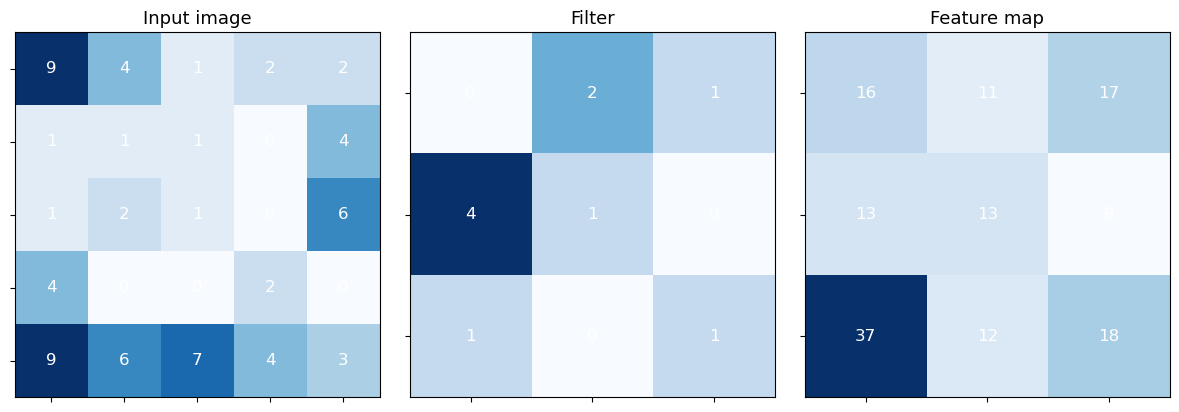

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
draw_matrix(axes[0], X, title="Input image")
draw_matrix(axes[1], K, title="Filter")
draw_matrix(axes[2], Y, title="Feature map")
plt.tight_layout()
plt.show()

## 实现池化层：最大池化和平均池化

这里我们用最基础的写法，不依赖深度学习框架。

In [8]:
def pool2d(X, pool_size=2, stride=2, mode="max"):
    """
    X: 输入特征图，形状 (H, W)
    pool_size: 池化窗口大小
    stride: 步长
    mode: "max" 或 "avg"
    """
    X = np.asarray(X, dtype=float)
    H, W = X.shape
    p = pool_size

    H_out = (H - p) // stride + 1
    W_out = (W - p) // stride + 1

    Z = np.zeros((H_out, W_out), dtype=float)

    for i in range(H_out):
        for j in range(W_out):
            h_start = i * stride
            h_end   = h_start + p
            w_start = j * stride
            w_end   = w_start + p

            window = X[h_start:h_end, w_start:w_end]

            if mode == "max":
                Z[i, j] = np.max(window)
            elif mode == "avg":
                Z[i, j] = np.mean(window)
            else:
                raise ValueError("mode must be 'max' or 'avg'")

    return Z

In [9]:
Z_max = pool2d(Y, pool_size=2, stride=1, mode="max")
Z_avg = pool2d(Y, pool_size=2, stride=1, mode="avg")

print("Convolution output Y =")
print(Y)

print("\nMax pooling result =")
print(Z_max)

print("\nAverage pooling result =")
print(Z_avg)

Convolution output Y =
[[16. 11. 17.]
 [13. 13.  8.]
 [37. 12. 18.]]

Max pooling result =
[[16. 17.]
 [37. 18.]]

Average pooling result =
[[13.25 12.25]
 [18.75 12.75]]


## 对应的池化公式解释

若卷积输出为：

$$
Y =
\begin{bmatrix}
16 & a & b \\
c  & d & e \\
f  & g & h
\end{bmatrix}
$$

那么左上角 $2\times2$ 池化窗口是：

$$
\begin{bmatrix}
16 & a \\
c  & d
\end{bmatrix}
$$

### 最大池化：

$$
Z_{max}[0,0] = \max(16, a, c, d)
$$

### 平均池化：

$$
Z_{avg}[0,0] = \frac{16 + a + c + d}{4}
$$

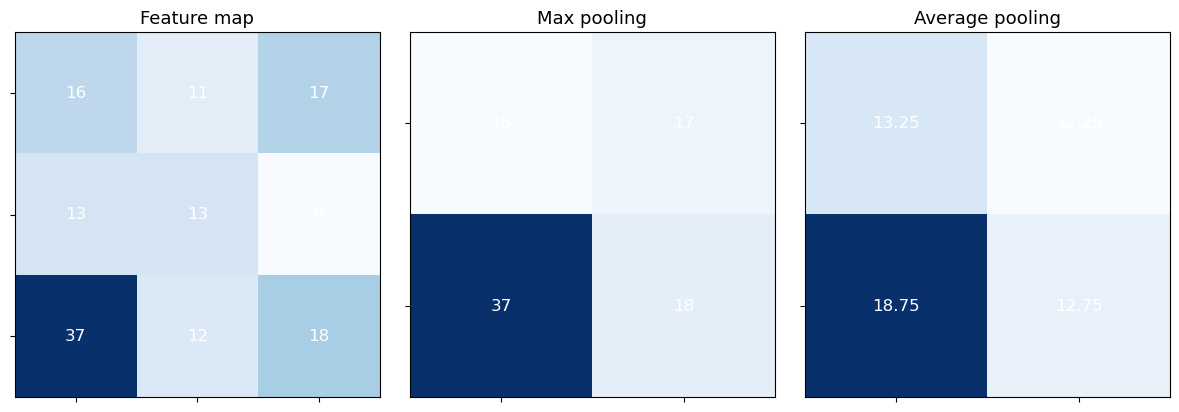

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
draw_matrix(axes[0], Y, title="Feature map")
draw_matrix(axes[1], Z_max, title="Max pooling")
draw_matrix(axes[2], Z_avg, title="Average pooling", fmt=".2f")
plt.tight_layout()
plt.show()

In [11]:
def explain_pool2d(X, pool_size=2, stride=1, mode="max"):
    X = np.asarray(X, dtype=float)
    H, W = X.shape
    p = pool_size

    H_out = (H - p) // stride + 1
    W_out = (W - p) // stride + 1

    Z = np.zeros((H_out, W_out), dtype=float)

    for i in range(H_out):
        for j in range(W_out):
            h_start = i * stride
            h_end   = h_start + p
            w_start = j * stride
            w_end   = w_start + p

            window = X[h_start:h_end, w_start:w_end]

            print("=" * 60)
            print(f"{mode.upper()} pooling -> Z[{i},{j}]")
            print("Window =")
            print(window)

            if mode == "max":
                value = np.max(window)
                print(f"max(window) = {value}")
            else:
                value = np.mean(window)
                print(f"mean(window) = {value}")

            Z[i, j] = value

    return Z

print("Explain MAX pooling")
_ = explain_pool2d(Y, pool_size=2, stride=1, mode="max")

print("\nExplain AVG pooling")
_ = explain_pool2d(Y, pool_size=2, stride=1, mode="avg")

Explain MAX pooling
MAX pooling -> Z[0,0]
Window =
[[16. 11.]
 [13. 13.]]
max(window) = 16.0
MAX pooling -> Z[0,1]
Window =
[[11. 17.]
 [13.  8.]]
max(window) = 17.0
MAX pooling -> Z[1,0]
Window =
[[13. 13.]
 [37. 12.]]
max(window) = 37.0
MAX pooling -> Z[1,1]
Window =
[[13.  8.]
 [12. 18.]]
max(window) = 18.0

Explain AVG pooling
AVG pooling -> Z[0,0]
Window =
[[16. 11.]
 [13. 13.]]
mean(window) = 13.25
AVG pooling -> Z[0,1]
Window =
[[11. 17.]
 [13.  8.]]
mean(window) = 12.25
AVG pooling -> Z[1,0]
Window =
[[13. 13.]
 [37. 12.]]
mean(window) = 18.75
AVG pooling -> Z[1,1]
Window =
[[13.  8.]
 [12. 18.]]
mean(window) = 12.75


In [12]:
def compute_conv_steps(X, K, bias=0.0, stride=1, padding=0):
    if padding > 0:
        X_padded = np.pad(X, ((padding, padding), (padding, padding)), mode='constant')
    else:
        X_padded = X.copy()

    H, W = X_padded.shape
    f = K.shape[0]
    H_out = (H - f) // stride + 1
    W_out = (W - f) // stride + 1

    steps = []
    Y_partial = np.full((H_out, W_out), np.nan)

    for i in range(H_out):
        for j in range(W_out):
            h_start = i * stride
            w_start = j * stride
            window = X_padded[h_start:h_start+f, w_start:w_start+f]
            prod = window * K
            value = np.sum(prod) + bias
            Y_partial[i, j] = value

            steps.append({
                "i": i,
                "j": j,
                "window": window.copy(),
                "prod": prod.copy(),
                "value": value,
                "h_start": h_start,
                "w_start": w_start,
                "Y_partial": Y_partial.copy()
            })
    return steps

conv_steps = compute_conv_steps(X, K)

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
ax_in, ax_k, ax_out = axes

def update_conv(frame):
    for ax in axes:
        ax.clear()

    step = conv_steps[frame]

    draw_matrix(ax_in, X, title=f"Input image\nwindow -> Y[{step['i']},{step['j']}]")
    rect = Rectangle((step["w_start"]-0.5, step["h_start"]-0.5), 3, 3, fill=False, linewidth=3)
    ax_in.add_patch(rect)

    draw_matrix(ax_k, K, title="Filter")

    partial = step["Y_partial"]
    visible = np.nan_to_num(partial, nan=0.0)
    draw_matrix(ax_out, visible, title=f"Feature map\nY[{step['i']},{step['j']}]={step['value']:.0f}")
    rect_out = Rectangle((step["j"]-0.5, step["i"]-0.5), 1, 1, fill=False, linewidth=3)
    ax_out.add_patch(rect_out)

    for i in range(partial.shape[0]):
        for j in range(partial.shape[1]):
            if np.isnan(partial[i, j]):
                ax_out.text(j, i, "", ha="center", va="center")

    plt.tight_layout()

anim_conv = FuncAnimation(fig, update_conv, frames=len(conv_steps), interval=1200, repeat=True)
plt.close(fig)
HTML(anim_conv.to_jshtml())

<Figure size 640x480 with 0 Axes>

In [14]:
def compute_pool_steps(X, pool_size=2, stride=1, mode="max"):
    X = np.asarray(X, dtype=float)
    H, W = X.shape
    p = pool_size

    H_out = (H - p) // stride + 1
    W_out = (W - p) // stride + 1

    steps = []
    Z_partial = np.full((H_out, W_out), np.nan)

    for i in range(H_out):
        for j in range(W_out):
            h_start = i * stride
            w_start = j * stride
            window = X[h_start:h_start+p, w_start:w_start+p]

            if mode == "max":
                value = np.max(window)
            else:
                value = np.mean(window)

            Z_partial[i, j] = value

            steps.append({
                "i": i,
                "j": j,
                "window": window.copy(),
                "value": value,
                "h_start": h_start,
                "w_start": w_start,
                "Z_partial": Z_partial.copy(),
                "mode": mode
            })
    return steps

max_steps = compute_pool_steps(Y, pool_size=2, stride=1, mode="max")
avg_steps = compute_pool_steps(Y, pool_size=2, stride=1, mode="avg")

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
ax_in, ax_out = axes

def update_pool_max(frame):
    for ax in axes:
        ax.clear()

    step = max_steps[frame]

    draw_matrix(ax_in, Y, title=f"Feature map\nmax pool window -> Z[{step['i']},{step['j']}]")
    rect = Rectangle((step["w_start"]-0.5, step["h_start"]-0.5), 2, 2, fill=False, linewidth=3)
    ax_in.add_patch(rect)

    visible = np.nan_to_num(step["Z_partial"], nan=0.0)
    draw_matrix(ax_out, visible, title=f"Max pooling\nZ[{step['i']},{step['j']}]={step['value']:.0f}")

    rect2 = Rectangle((step["j"]-0.5, step["i"]-0.5), 1, 1, fill=False, linewidth=3)
    ax_out.add_patch(rect2)
    plt.tight_layout()

anim_max = FuncAnimation(fig, update_pool_max, frames=len(max_steps), interval=1400, repeat=True)
plt.close(fig)
HTML(anim_max.to_jshtml())

<Figure size 640x480 with 0 Axes>

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
ax_in, ax_out = axes

def update_pool_avg(frame):
    for ax in axes:
        ax.clear()

    step = avg_steps[frame]

    draw_matrix(ax_in, Y, title=f"Feature map\navg pool window -> Z[{step['i']},{step['j']}]")
    rect = Rectangle((step["w_start"]-0.5, step["h_start"]-0.5), 2, 2, fill=False, linewidth=3)
    ax_in.add_patch(rect)

    visible = np.nan_to_num(step["Z_partial"], nan=0.0)
    draw_matrix(ax_out, visible, title=f"Average pooling\nZ[{step['i']},{step['j']}]={step['value']:.2f}", fmt=".2f")

    rect2 = Rectangle((step["j"]-0.5, step["i"]-0.5), 1, 1, fill=False, linewidth=3)
    ax_out.add_patch(rect2)
    plt.tight_layout()

anim_avg = FuncAnimation(fig, update_pool_avg, frames=len(avg_steps), interval=1400, repeat=True)
plt.close(fig)
HTML(anim_avg.to_jshtml())

<Figure size 640x480 with 0 Axes>

In [17]:
X = np.array([
    [ 1,  2, -2, -1],
    [ 2, -1,  0,  3],
    [-1,  0, -1,  2],
    [-1, -2,  2,  1]
], dtype=float)

pool_size = 2
stride = 2

print("Feature map X =")
print(X)
print("\npool_size =", pool_size)
print("stride =", stride)

Feature map X =
[[ 1.  2. -2. -1.]
 [ 2. -1.  0.  3.]
 [-1.  0. -1.  2.]
 [-1. -2.  2.  1.]]

pool_size = 2
stride = 2


In [19]:
Y_max = pool2d(X, pool_size=2, stride=2, mode="max")
Y_avg = pool2d(X, pool_size=2, stride=2, mode="avg")

print("Max pooling result:")
print(Y_max)

print("\nAverage pooling result:")
print(Y_avg)

Max pooling result:
[[2. 3.]
 [0. 2.]]

Average pooling result:
[[ 1.  0.]
 [-1.  1.]]


In [18]:
Y_max = explain_pool2d(X, pool_size=2, stride=2, mode="max")
Y_avg = explain_pool2d(X, pool_size=2, stride=2, mode="avg")

print("Max pooling result:")
print(Y_max)

print("\nAverage pooling result:")
print(Y_avg)

MAX pooling -> Z[0,0]
Window =
[[ 1.  2.]
 [ 2. -1.]]
max(window) = 2.0
MAX pooling -> Z[0,1]
Window =
[[-2. -1.]
 [ 0.  3.]]
max(window) = 3.0
MAX pooling -> Z[1,0]
Window =
[[-1.  0.]
 [-1. -2.]]
max(window) = 0.0
MAX pooling -> Z[1,1]
Window =
[[-1.  2.]
 [ 2.  1.]]
max(window) = 2.0
AVG pooling -> Z[0,0]
Window =
[[ 1.  2.]
 [ 2. -1.]]
mean(window) = 1.0
AVG pooling -> Z[0,1]
Window =
[[-2. -1.]
 [ 0.  3.]]
mean(window) = 0.0
AVG pooling -> Z[1,0]
Window =
[[-1.  0.]
 [-1. -2.]]
mean(window) = -1.0
AVG pooling -> Z[1,1]
Window =
[[-1.  2.]
 [ 2.  1.]]
mean(window) = 1.0
Max pooling result:
[[2. 3.]
 [0. 2.]]

Average pooling result:
[[ 1.  0.]
 [-1.  1.]]


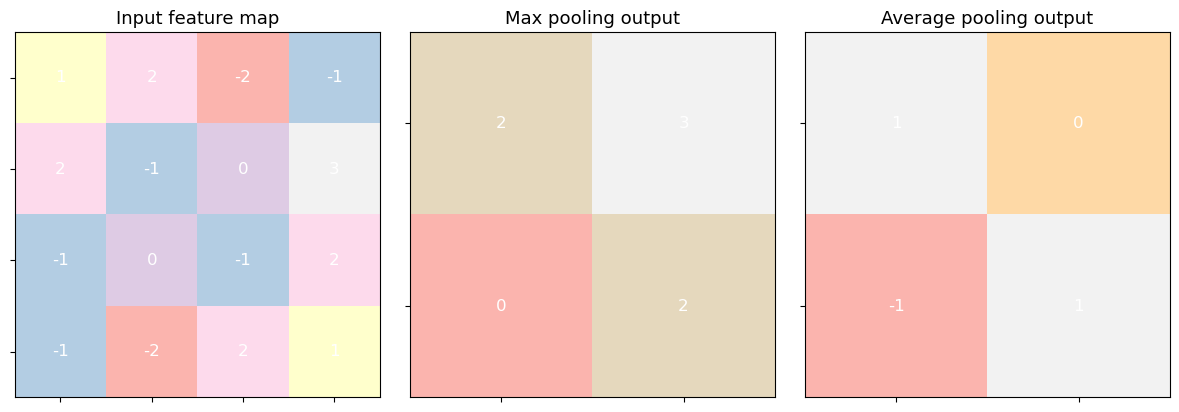

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
draw_matrix(axes[0], X, title="Input feature map",cmap="Pastel1")
draw_matrix(axes[1], Y_max, title="Max pooling output",cmap="Pastel1")
draw_matrix(axes[2], Y_avg, title="Average pooling output",cmap="Pastel1")
plt.tight_layout()
plt.show()

In [22]:
steps_max = compute_pool_steps(X, pool_size=2, stride=2, mode="max")
steps_avg = compute_pool_steps(X, pool_size=2, stride=2, mode="avg")

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
ax_in, ax_out = axes

def update_max(frame):
    for ax in axes:
        ax.clear()

    step = steps_max[frame]

    draw_matrix(ax_in, X, title=f"Feature map\nmax pool window -> Y[{step['i']},{step['j']}]",cmap="Pastel1")
    rect = Rectangle((step["w_start"]-0.5, step["h_start"]-0.5), 2, 2, fill=False, linewidth=3)
    ax_in.add_patch(rect)

    partial = np.nan_to_num(step["Z_partial"], nan=0.0)
    draw_matrix(ax_out, partial, title=f"Max pooling output\nY[{step['i']},{step['j']}]={step['value']:.0f}",cmap="Pastel1")

    rect2 = Rectangle((step["j"]-0.5, step["i"]-0.5), 1, 1, fill=False, linewidth=3)
    ax_out.add_patch(rect2)
    plt.tight_layout()

anim_max = FuncAnimation(fig, update_max, frames=len(steps_max), interval=1400, repeat=True)
plt.close(fig)
HTML(anim_max.to_jshtml())

<Figure size 640x480 with 0 Axes>

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
ax_in, ax_out = axes

def update_max(frame):
    for ax in axes:
        ax.clear()

    step = steps_max[frame]

    draw_matrix(ax_in, X, title=f"Feature map\nmax pool window -> Y[{step['i']},{step['j']}]")
    rect = Rectangle((step["w_start"]-0.5, step["h_start"]-0.5), 2, 2, fill=False, linewidth=3)
    ax_in.add_patch(rect)

    partial = np.nan_to_num(step["Z_partial"], nan=0.0)
    draw_matrix(ax_out, partial, title=f"Max pooling output\nY[{step['i']},{step['j']}]={step['value']:.0f}")

    rect2 = Rectangle((step["j"]-0.5, step["i"]-0.5), 1, 1, fill=False, linewidth=3)
    ax_out.add_patch(rect2)
    plt.tight_layout()

anim_max = FuncAnimation(fig, update_max, frames=len(steps_max), interval=1400, repeat=True)
plt.close(fig)
HTML(anim_max.to_jshtml())

<Figure size 640x480 with 0 Axes>